# Yelp Sentiment Analysis with doc2vec Document Vectors

## Imports & Settings

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import nltk

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\paxto\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
from pathlib import Path
import logging
from random import shuffle

import numpy as np
import pandas as pd

from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument

from nltk import RegexpTokenizer
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.utils import class_weight

import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

### Settings

In [4]:
sns.set_style("white")
pd.set_option("display.expand_frame_repr", False)
np.random.seed(42)

### Paths

In [5]:
data_path = Path("..", "data", "yelp")

In [6]:
results_path = Path("results", "yelp")
if not results_path.exists():
    results_path.mkdir(parents=True)

### Logging Config

In [7]:
logging.basicConfig(
    filename=results_path / "doc2vec.log",
    level=logging.DEBUG,
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    datefmt="%H:%M:%S",
)

## Load Data

Refer to download information [here](../data/create_yelp_review_data.ipynb).

We'll create a smaller sample of 100,000 reviews per star rating.

In [8]:
df = pd.read_parquet(data_path / "user_reviews.parquet").loc[:, ["stars", "text"]]

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6990280 entries, 0 to 6990279
Data columns (total 2 columns):
 #   Column  Dtype  
---  ------  -----  
 0   stars   float64
 1   text    object 
dtypes: float64(1), object(1)
memory usage: 106.7+ MB


In [10]:
df.stars.value_counts()

stars
5.0    3231627
4.0    1452918
1.0    1069561
3.0     691934
2.0     544240
Name: count, dtype: int64

In [11]:
stars = range(1, 6)

In [12]:
sample = pd.concat([df[df.stars == s].sample(n=100000) for s in stars])

In [13]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500000 entries, 341557 to 1820664
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   stars   500000 non-null  float64
 1   text    500000 non-null  object 
dtypes: float64(1), object(1)
memory usage: 11.4+ MB


In [14]:
sample.stars.value_counts()

stars
1.0    100000
2.0    100000
3.0    100000
4.0    100000
5.0    100000
Name: count, dtype: int64

In [15]:
sample.to_parquet(results_path / "review_sample.parquet")

In [16]:
sample = pd.read_parquet(results_path / "review_sample.parquet").reset_index(drop=True)

In [17]:
sample.head()

,stars,text
0,1.0,They leave the door to the ladies changing roo...
1,1.0,This place is a joke..... they say it's all yo...
2,1.0,Bad breakfast. Grits are not good. Pulled pork...
3,1.0,I visited The Mud House because I heard they h...
4,1.0,Went there at 11:20am. Thought they opened at ...


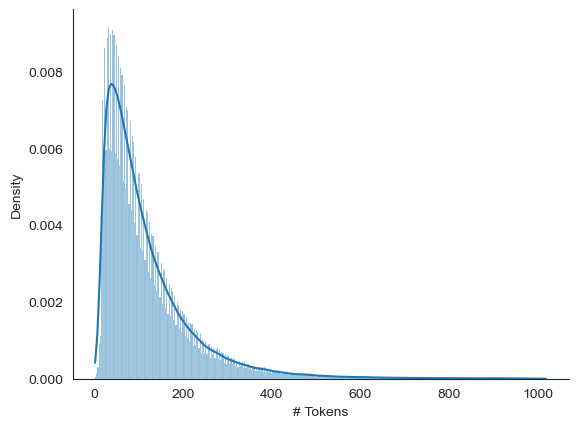

In [18]:
ax = sns.histplot(sample.text.str.split().str.len(), kde=True, stat="density")
ax.set_xlabel("# Tokens")
sns.despine();

## Doc2Vec

### Basic text cleaning

In [19]:
tokenizer = RegexpTokenizer(r"\w+")
stopword_set = set(stopwords.words("english"))


def clean(review):
    tokens = tokenizer.tokenize(review)
    return " ".join([t for t in tokens if t not in stopword_set])

In [20]:
sample.text = sample.text.str.lower().apply(clean)

In [21]:
sample.sample(n=10)

,stars,text
93418,1.0,absolutely horrible cajun pasta tastes like no...
431214,5.0,update 2 17 17 wrote earlier staff front desk ...
326177,4.0,family love restaurant hi end fine dining stan...
146943,2.0,cookie dough shake three disappointed first 14...
32636,1.0,ask female nail tech drop hand yell across roo...
442157,5.0,wildest coolest dining experience ever chef ya...
98766,1.0,would even give store one star let november 29...
137409,2.0,good tour information expensive many alternati...
170784,2.0,nothing brag steak tacos bland clean environme...
406714,5.0,wow well worth visit peter carl fabergé egg co...


In [22]:
sample = sample[sample.text.str.split().str.len() > 10]
sample.info()

<class 'pandas.core.frame.DataFrame'>
Index: 485347 entries, 0 to 499999
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   stars   485347 non-null  float64
 1   text    485347 non-null  object 
dtypes: float64(1), object(1)
memory usage: 11.1+ MB


### Create sentence stream

In [23]:
sentences = []
for i, (_, text) in enumerate(sample.values):
    sentences.append(TaggedDocument(words=text.split(), tags=[i]))

### Formulate the model

In [25]:
model = Doc2Vec(
    documents=sentences,
    dm=1,  # 1=distributed memory, 0=dist.BOW
    epochs=5,
    vector_size=300,  # vector size
    window=5,  # max. distance betw. target and context
    min_count=50,  # ignore tokens w. lower frequency
    negative=5,  # negative training samples
    dm_concat=0,  # 1=concatenate vectors, 0=sum
    dbow_words=0,  # 1=train word vectors as well
    workers=4,
)

In [27]:
pd.DataFrame(model.wv.most_similar("good"), columns=["token", "similarity"])

,token,similarity
0,great,0.761615
1,decent,0.741287
2,tasty,0.636088
3,ok,0.635163
4,amazing,0.625220
5,excellent,0.624632
6,awesome,0.618558
7,delicious,0.600493
8,fantastic,0.595684
9,bad,0.594723


### Continue training

In [28]:
model.train(sentences, total_examples=model.corpus_count, epochs=model.epochs)

In [29]:
most_similar = pd.DataFrame(
    model.wv.most_similar("good"), columns=["token", "similarity"]
)
most_similar

,token,similarity
0,great,0.744362
1,decent,0.703694
2,amazing,0.616213
3,excellent,0.608078
4,fantastic,0.591757
5,awesome,0.581737
6,tasty,0.579161
7,delicious,0.569213
8,ok,0.550437
9,yummy,0.532896


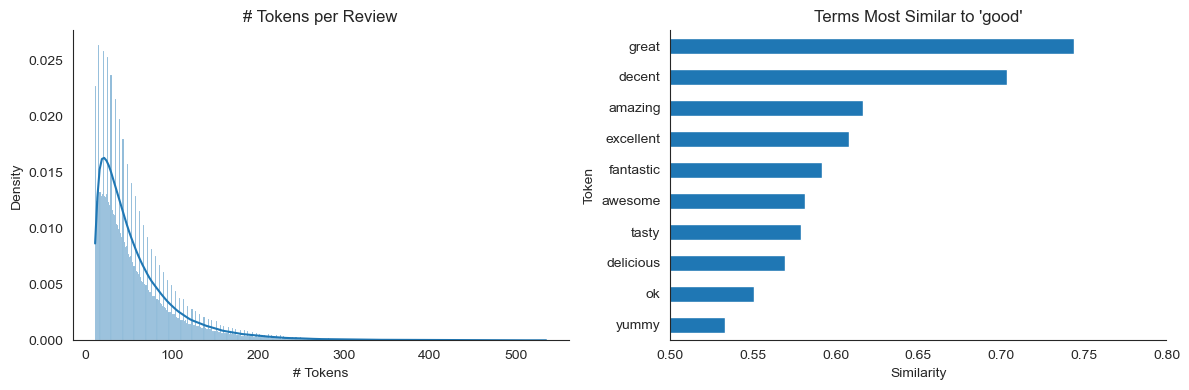

In [30]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 4))
sns.histplot(sample.text.str.split().str.len(), ax=axes[0], kde=True, stat="density")
axes[0].set_title("# Tokens per Review")

most_similar.set_index("token").similarity.sort_values().plot.barh(
    ax=axes[1], title="Terms Most Similar to 'good'", xlim=(0.5, 0.8)
)
axes[1].set_xlabel("Similarity")
axes[1].set_ylabel("Token")
axes[0].set_xlabel("# Tokens")

sns.despine()
fig.tight_layout()
fig.savefig(results_path / "doc2vec_stats", dpi=300)

## Persist Model

In [31]:
model.save((results_path / "sample.model").as_posix())

In [32]:
model = Doc2Vec.load((results_path / "sample.model").as_posix())

## Evaluate

In [33]:
y = sample.stars.sub(1)

In [34]:
size = 300
X = np.zeros(shape=(len(y), size))
for i in range(len(sample)):
    X[i] = model.docvecs[i]

In [35]:
X.shape

(485347, 300)

### Train-Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [37]:
mode = pd.Series(y_train).mode().iloc[0]
baseline = accuracy_score(y_true=y_test, y_pred=np.full_like(y_test, fill_value=mode))
print(f"Baseline Score: {baseline:.2%}")

Baseline Score: 20.16%


In [39]:
class_weights = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train
)

In [40]:
class_weights

array([0.99716729, 0.99180556, 0.99559482, 1.0014366 , 1.01429448])

## LightGBM

In [41]:
train_data = lgb.Dataset(data=X_train, label=y_train)
test_data = train_data.create_valid(X_test, label=y_test)

In [42]:
params = {"objective": "multiclass", "num_classes": 5}

In [45]:
lgb_model = lgb.train(
    params=params,
    train_set=train_data,
    num_boost_round=5000,
    valid_sets=[train_data, test_data],
    callbacks=[lgb.early_stopping(25), lgb.log_evaluation(period=50)],
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.290648 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 76500
[LightGBM] [Info] Number of data points in the train set: 388277, number of used features: 300
[LightGBM] [Info] Start training from score -1.606601
[LightGBM] [Info] Start training from score -1.601210
[LightGBM] [Info] Start training from score -1.605023
[LightGBM] [Info] Start training from score -1.610873
[LightGBM] [Info] Start training from score -1.623631
Training until validation scores don't improve for 25 rounds
[50]	training's multi_logloss: 1.40568	valid_1's multi_logloss: 1.43275
[100]	training's multi_logloss: 1.33283	valid_1's multi_logloss: 1.38399
[150]	training's multi_logloss: 1.27789	valid_1's multi_logloss: 1.35044
[200]	training's multi_logloss: 1.23442	valid_1's multi_logloss: 1.32783
[250]	training's multi_logloss: 1.19878	valid_1's multi_logloss: 1.31275
[300]	trainin

In [46]:
lgb_pred = np.argmax(lgb_model.predict(X_test), axis=1)

In [47]:
lgb_acc = accuracy_score(y_true=y_test, y_pred=lgb_pred)
print(f"Accuracy: {lgb_acc:.2%}")

Accuracy: 56.70%


## Random Forest

In [48]:
rf = RandomForestClassifier(
    n_jobs=-1, n_estimators=500, verbose=1, class_weight="balanced_subsample"
)
rf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:   39.0s
[Parallel(n_jobs=-1)]: Done 164 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done 414 tasks      | elapsed: 14.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 17.5min finished


,n_estimators,500
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_true=y_test, y_pred=rf_pred)
print(f"Accuracy: {rf_acc:.2%}")

[Parallel(n_jobs=18)]: Using backend ThreadingBackend with 18 concurrent workers.
[Parallel(n_jobs=18)]: Done  14 tasks      | elapsed:    0.6s
[Parallel(n_jobs=18)]: Done 164 tasks      | elapsed:    4.4s
[Parallel(n_jobs=18)]: Done 414 tasks      | elapsed:   11.5s
[Parallel(n_jobs=18)]: Done 500 out of 500 | elapsed:   13.7s finished


Accuracy: 37.05%


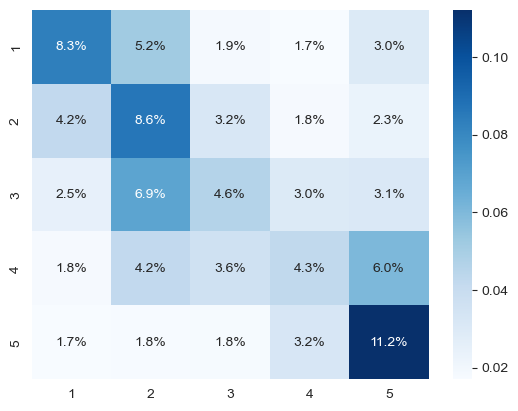

In [50]:
cm = confusion_matrix(y_true=y_test, y_pred=rf_pred)
sns.heatmap(
    pd.DataFrame(cm / np.sum(cm), index=stars, columns=stars),
    annot=True,
    cmap="Blues",
    fmt=".1%",
);

## Multinomial Logistic Regression

In [51]:
lr = LogisticRegression(
    multi_class="multinomial", solver="lbfgs", class_weight="balanced"
)
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'multinomial'


In [52]:
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_true=y_test, y_pred=lr_pred)
print(f"Accuracy: {lr_acc:.2%}")

Accuracy: 34.17%


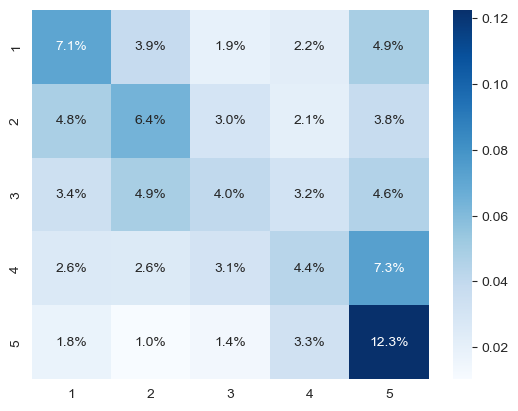

In [53]:
cm = confusion_matrix(y_true=y_test, y_pred=lr_pred)
sns.heatmap(
    pd.DataFrame(cm / np.sum(cm), index=stars, columns=stars),
    annot=True,
    cmap="Blues",
    fmt=".1%",
);

## Comparison

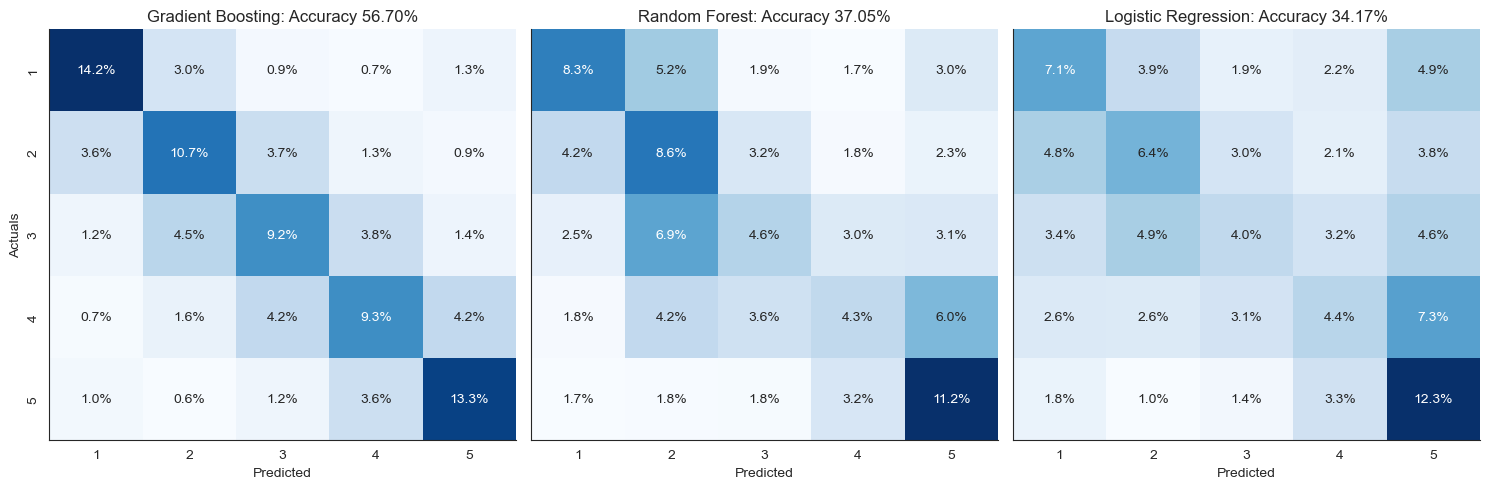

In [54]:
fig, axes = plt.subplots(ncols=3, figsize=(15, 5), sharex=True, sharey=True)

lgb_cm = confusion_matrix(y_true=y_test, y_pred=lgb_pred)
sns.heatmap(
    pd.DataFrame(lgb_cm / np.sum(lgb_cm), index=stars, columns=stars),
    annot=True,
    cmap="Blues",
    fmt=".1%",
    ax=axes[0],
    cbar=False,
)
axes[0].set_title(f"Gradient Boosting: Accuracy {lgb_acc:.2%}")

rf_cm = confusion_matrix(y_true=y_test, y_pred=rf_pred)
sns.heatmap(
    pd.DataFrame(rf_cm / np.sum(rf_cm), index=stars, columns=stars),
    annot=True,
    cmap="Blues",
    fmt=".1%",
    ax=axes[1],
    cbar=False,
)
axes[1].set_title(f"Random Forest: Accuracy {rf_acc:.2%}")

lr_cm = confusion_matrix(y_true=y_test, y_pred=lr_pred)
sns.heatmap(
    pd.DataFrame(lr_cm / np.sum(lr_cm), index=stars, columns=stars),
    annot=True,
    cmap="Blues",
    fmt=".1%",
    ax=axes[2],
    cbar=False,
)
axes[2].set_title(f"Logistic Regression: Accuracy {lr_acc:.2%}")
axes[0].set_ylabel("Actuals")
for i in range(3):
    axes[i].set_xlabel("Predicted")

sns.despine()
fig.tight_layout()
fig.savefig(results_path / "confusion_matrix", dpi=300)